In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("motor_kenya_insurance.csv")

df.head()

,Year,Policy_ID,Customer_Age,Gender,Region,Vehicle_Type,Vehicle_Age,Vehicle_Value_KES,Vehicle_Engine_Capacity,Use_Purpose,Annual_Premium_KES,Claims_Frequency,Total_Claim_Amount_KES,No_Claim_Bonus_%,Accident_Cause,Policy_Term_Months,Previous_Claims_Count,Driver_Experience_Years,Third_Party_Only
0,2023,P202300001,58,Male,Nakuru,PSV,19,3229084,2000,Business,203851,1,866500,0,Theft,6,0,38,Yes
1,2023,P202300002,43,Male,Thika,Private,3,1739911,2000,Taxi,64471,0,0,20,NaN,6,2,22,No
2,2023,P202300003,40,Male,Kakamega,Private,0,2781931,1500,Business,146378,0,0,50,NaN,12,0,22,Yes
3,2023,P202300004,46,Male,Nakuru,Private,9,1154811,2500,Personal,59810,0,0,30,NaN,12,0,26,No
4,2023,P202300005,63,Female,Nakuru,Commercial,19,3452991,1000,Business,143266,0,0,30,NaN,6,0,41,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Year                     2000 non-null   int64 
 1   Policy_ID                2000 non-null   object
 2   Customer_Age             2000 non-null   int64 
 3   Gender                   2000 non-null   object
 4   Region                   2000 non-null   object
 5   Vehicle_Type             2000 non-null   object
 6   Vehicle_Age              2000 non-null   int64 
 7   Vehicle_Value_KES        2000 non-null   int64 
 8   Vehicle_Engine_Capacity  2000 non-null   int64 
 9   Use_Purpose              2000 non-null   object
 10  Annual_Premium_KES       2000 non-null   int64 
 11  Claims_Frequency         2000 non-null   int64 
 12  Total_Claim_Amount_KES   2000 non-null   int64 
 13  No_Claim_Bonus_%         2000 non-null   int64 
 14  Accident_Cause           662 non-null   

In [4]:
df.describe()

,Year,Customer_Age,Vehicle_Age,Vehicle_Value_KES,Vehicle_Engine_Capacity,Annual_Premium_KES,Claims_Frequency,Total_Claim_Amount_KES,No_Claim_Bonus_%,Policy_Term_Months,Previous_Claims_Count,Driver_Experience_Years
count,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000,2000.00000,2000.000000
mean,2023.500000,44.440000,9.574000,1.993016e+06,2023.250000,99395.798500,0.408500,2.019854e+05,18.505000,8.928000,0.30900,24.540000
std,0.500125,14.424577,5.718205,1.167647e+06,700.770988,63599.182858,0.650261,4.285867e+05,17.798128,2.999886,0.56096,14.408477
min,2023.000000,20.000000,0.000000,5.076700e+04,1000.000000,1885.000000,0.000000,0.000000e+00,0.000000,6.000000,0.00000,1.000000
25%,2023.000000,32.000000,5.000000,1.114232e+06,1500.000000,53708.750000,0.000000,0.000000e+00,0.000000,6.000000,0.00000,12.000000
50%,2023.500000,44.000000,10.000000,1.942366e+06,2000.000000,89858.500000,0.000000,0.000000e+00,20.000000,6.000000,0.00000,24.000000
75%,2024.000000,57.000000,15.000000,2.757036e+06,2500.000000,137527.750000,1.000000,1.642250e+05,30.000000,12.000000,1.00000,37.000000
max,2024.000000,69.000000,19.000000,4.984737e+06,3000.000000,333305.000000,5.000000,2.916800e+06,50.000000,12.000000,3.00000,51.000000


In [5]:
df.shape

(2000, 19)

In [6]:
df.columns

Index(['Year', 'Policy_ID', 'Customer_Age', 'Gender', 'Region', 'Vehicle_Type',
       'Vehicle_Age', 'Vehicle_Value_KES', 'Vehicle_Engine_Capacity',
       'Use_Purpose', 'Annual_Premium_KES', 'Claims_Frequency',
       'Total_Claim_Amount_KES', 'No_Claim_Bonus_%', 'Accident_Cause',
       'Policy_Term_Months', 'Previous_Claims_Count',
       'Driver_Experience_Years', 'Third_Party_Only'],
      dtype='object')

In [7]:

df_sev = df[df['Claims_Frequency'] > 0].copy()
df_sev['Severity'] = df_sev['Total_Claim_Amount_KES'] / df_sev['Claims_Frequency']

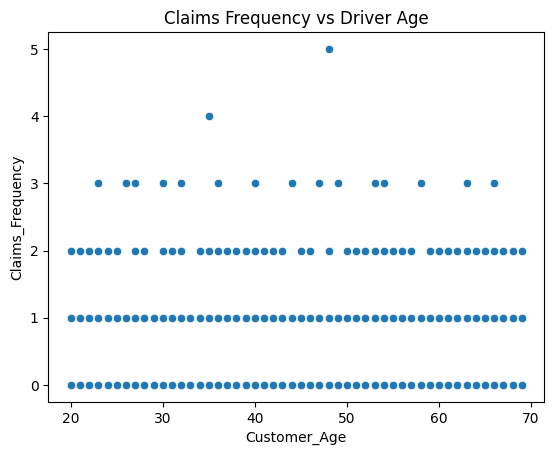

In [8]:
sns.scatterplot(x='Customer_Age', y='Claims_Frequency', data=df)
plt.title("Claims Frequency vs Driver Age")
plt.show()

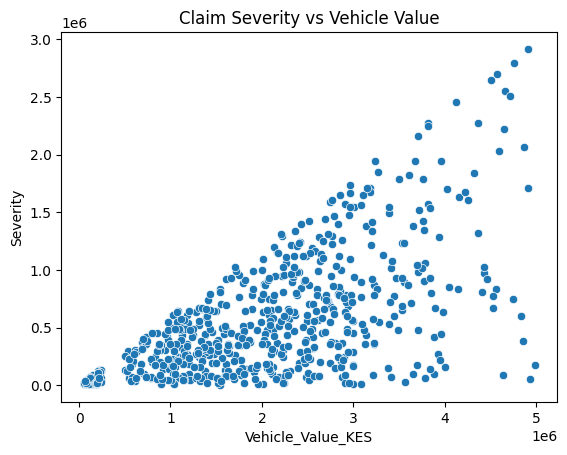

In [9]:
sns.scatterplot(x='Vehicle_Value_KES', y='Severity', data=df_sev)
plt.title("Claim Severity vs Vehicle Value")
plt.show()

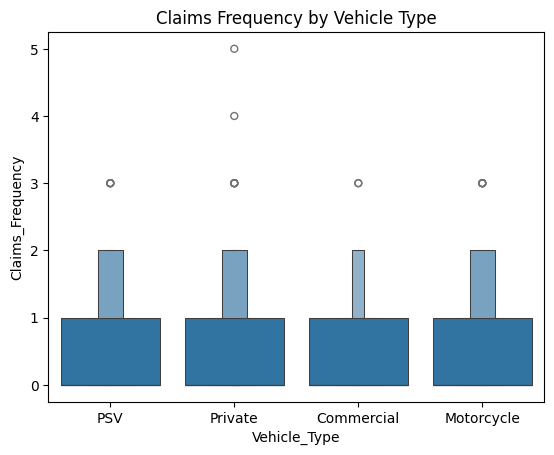

In [10]:
sns.boxenplot(x='Vehicle_Type', y='Claims_Frequency', data=df)
plt.title("Claims Frequency by Vehicle Type")
plt.show()

In [11]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

freq_model = smf.glm(
    formula='Claims_Frequency ~ Customer_Age + Gender + Vehicle_Age + Vehicle_Type + Vehicle_Engine_Capacity + Region + Use_Purpose + Driver_Experience_Years',
    data=df,
    family=sm.families.Poisson()
).fit()

print(freq_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       Claims_Frequency   No. Observations:                 2000
Model:                            GLM   Df Residuals:                     1982
Model Family:                 Poisson   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1655.1
Date:                Thu, 19 Mar 2026   Deviance:                       1896.7
Time:                        08:45:42   Pearson chi2:                 2.03e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01069
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [12]:
df_claims = df[df['Total_Claim_Amount_KES'] > 0].copy()

df_claims.head()

,Year,Policy_ID,Customer_Age,Gender,Region,Vehicle_Type,Vehicle_Age,Vehicle_Value_KES,Vehicle_Engine_Capacity,Use_Purpose,Annual_Premium_KES,Claims_Frequency,Total_Claim_Amount_KES,No_Claim_Bonus_%,Accident_Cause,Policy_Term_Months,Previous_Claims_Count,Driver_Experience_Years,Third_Party_Only
0,2023,P202300001,58,Male,Nakuru,PSV,19,3229084,2000,Business,203851,1,866500,0,Theft,6,0,38,Yes
5,2023,P202300006,28,Male,Thika,Private,6,2946609,2500,Business,187760,1,684500,0,Weather,6,0,9,Yes
11,2023,P202300012,36,Male,Meru,Private,7,2611138,2000,Personal,161845,1,564800,0,Collision,12,0,18,Yes
12,2023,P202300013,27,Female,Kakamega,Private,11,851279,3000,Personal,38950,1,453700,0,Theft,12,0,5,Yes
13,2023,P202300014,66,Female,Kakamega,Private,13,1706914,1000,Personal,100340,1,266000,0,Weather,12,0,47,No


In [13]:
sev_model = smf.glm(
    formula='Total_Claim_Amount_KES ~ Customer_Age + Vehicle_Age + Vehicle_Type',
    data=df_claims,
    family=sm.families.Gamma(link=sm.families.links.inverse_power())
).fit()

print(sev_model.summary())

                   Generalized Linear Model Regression Results                    
Dep. Variable:     Total_Claim_Amount_KES   No. Observations:                  662
Model:                                GLM   Df Residuals:                      656
Model Family:                       Gamma   Df Model:                            5
Link Function:              inverse_power   Scale:                         0.53022
Method:                              IRLS   Log-Likelihood:                -9321.1
Date:                    Thu, 19 Mar 2026   Deviance:                       478.55
Time:                            08:45:42   Pearson chi2:                     348.
No. Iterations:                        10   Pseudo R-squ. (CS):             0.5421
Covariance Type:                nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The inverse_power link alias is deprecated. Use InversePower instead. The inverse_power link alias will be removed after the 0.15.0 release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The inverse_power link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


In [14]:
df['Pred_Severity'] = 0

df.loc[df['Total_Claim_Amount_KES'] > 0, 'Pred_Severity'] = sev_model.predict(df_claims)

/tmp/ipykernel_161/1661701146.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 769734.17146201  526529.17812792  529074.75564403  515278.90145914
  533752.2827784   526820.04377357  554591.64356589  823961.75818699
  532371.91026507  868699.9077055   529368.44133236  876317.49089681
  536431.98458239  541314.25981108  927833.25792116  991613.68303539
   50745.02876645  941018.47066156  507219.15492653  521563.19016674
  737166.67494498  528950.97764769  812137.8377907   514656.52143945
   50594.33759753  553413.75264142  514261.93051984  519893.90868676
  804632.8234433   512972.88894841  534185.51501748  531224.00592128
  543376.79675422   50398.63771393  541500.35434641  832281.73677628
  517775.88822843  945958.73397772  538465.69804434  801908.00137648
  915915.17602579  528542.15298364  939334.92352959  798618.74205084
  509086.92696081  539267.32151798  865979.18981111  529910.73390349
  55120

In [15]:
df['Pred_Frequency'] = freq_model.predict(df)

df[['Pred_Frequency']].head()

,Pred_Frequency
0,0.470408
1,0.309343
2,0.312246
3,0.514757
4,0.334821


In [16]:
df['Pred_Severity'] = sev_model.predict(df)

predicting cost and severity

In [17]:
df['Pure_Premium_KES'] = df['Pred_Frequency'] * df['Pred_Severity']

df[['Policy_ID','Pred_Frequency','Pred_Severity','Pure_Premium_KES']].head()

,Policy_ID,Pred_Frequency,Pred_Severity,Pure_Premium_KES
0,P202300001,0.470408,769734.171462,362089.041107
1,P202300002,0.309343,542376.092982,167780.150095
2,P202300003,0.312246,547491.654813,170952.312149
3,P202300004,0.514757,530624.795465,273142.706977
4,P202300005,0.334821,889399.605336,297789.306500


In [18]:
df.groupby('Vehicle_Type')['Pure_Premium_KES'].mean()

,Pure_Premium_KES
Vehicle_Type,
Commercial,333151.238749
Motorcycle,23223.201077
PSV,359495.454434
Private,215064.649171


In [19]:
df.groupby('Region')['Pure_Premium_KES'].mean()

,Pure_Premium_KES
Region,
Eldoret,251159.756605
Kakamega,212147.949491
Kisumu,219809.065634
Meru,252520.754594
Mombasa,272523.726892
Nairobi,256385.256958
Nakuru,282398.440406
Thika,235245.007917


In [20]:
df.groupby('Use_Purpose')['Pure_Premium_KES'].mean()

,Pure_Premium_KES
Use_Purpose,
Business,226884.697193
Personal,264682.440136
Taxi,203723.067675


In [21]:
df_sorted = df.sort_values(by='Pure_Premium_KES', ascending=False)

df_sorted[['Policy_ID','Vehicle_Type','Region','Pred_Frequency','Pred_Severity','Pure_Premium_KES']].head(10)

,Policy_ID,Vehicle_Type,Region,Pred_Frequency,Pred_Severity,Pure_Premium_KES
1040,P202400041,PSV,Nakuru,0.602640,8.503259e+05,512439.986950
1232,P202400233,Commercial,Nakuru,0.490454,1.006046e+06,493419.093857
1071,P202400072,Commercial,Nakuru,0.483423,1.001539e+06,484167.511472
527,P202300528,PSV,Nakuru,0.601007,8.049193e+05,483761.807976
718,P202300719,PSV,Nakuru,0.575834,8.310888e+05,478569.546058
1297,P202400298,PSV,Nakuru,0.602826,7.852871e+05,473391.433839
862,P202300863,PSV,Nakuru,0.587335,8.054743e+05,473083.603888
151,P202300152,PSV,Mombasa,0.582938,8.107382e+05,472609.712023
154,P202300155,PSV,Eldoret,0.540634,8.686999e+05,469649.000895
77,P202300078,Commercial,Nairobi,0.450913,1.030283e+06,464568.064858


Top 10 highest premium policies

In [22]:
df_sorted[['Policy_ID','Vehicle_Type','Region','Pure_Premium_KES']].tail(10)

,Policy_ID,Vehicle_Type,Region,Pure_Premium_KES
1084,P202400085,Motorcycle,Thika,17184.676634
800,P202300801,Motorcycle,Kisumu,17146.989034
1544,P202400545,Motorcycle,Eldoret,17035.694157
1074,P202400075,Motorcycle,Thika,16941.779606
230,P202300231,Motorcycle,Kakamega,16759.279822
1209,P202400210,Motorcycle,Kakamega,16741.305225
1349,P202400350,Motorcycle,Kakamega,16696.557564
1763,P202400764,Motorcycle,Kisumu,16030.003307
1556,P202400557,Motorcycle,Thika,15672.470072
1669,P202400670,Motorcycle,Kakamega,15115.192407


Bottom 10 lowest premium policies

In [23]:
vehicle_pricing = df.groupby('Vehicle_Type')['Pure_Premium_KES'].mean().sort_values(ascending=False)

vehicle_pricing

,Pure_Premium_KES
Vehicle_Type,
PSV,359495.454434
Commercial,333151.238749
Private,215064.649171
Motorcycle,23223.201077


Average pure premium by vehicle type

In [24]:
base = vehicle_pricing.min()

relativity = vehicle_pricing / base

relativity

,Pure_Premium_KES
Vehicle_Type,
PSV,15.480013
Commercial,14.345621
Private,9.260767
Motorcycle,1.000000


In [25]:
df.groupby('Region')['Pure_Premium_KES'].mean().sort_values(ascending=False)

,Pure_Premium_KES
Region,
Nakuru,282398.440406
Mombasa,272523.726892
Nairobi,256385.256958
Meru,252520.754594
Eldoret,251159.756605
Thika,235245.007917
Kisumu,219809.065634
Kakamega,212147.949491


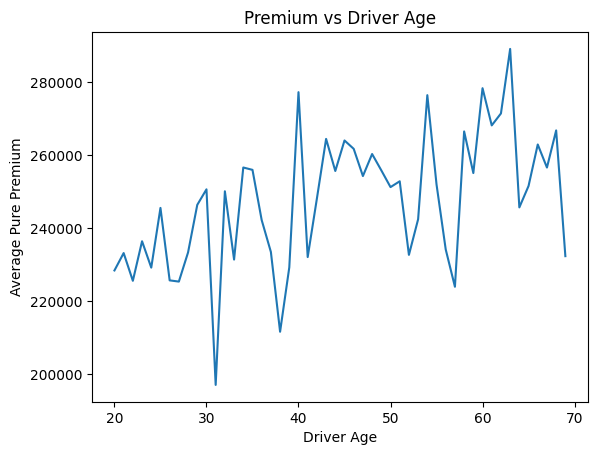

In [29]:
df.groupby('Customer_Age')['Pure_Premium_KES'].mean().plot()

plt.title("Premium vs Driver Age")
plt.xlabel("Driver Age")
plt.ylabel("Average Pure Premium")
plt.show()

<Axes: xlabel='Vehicle_Type'>

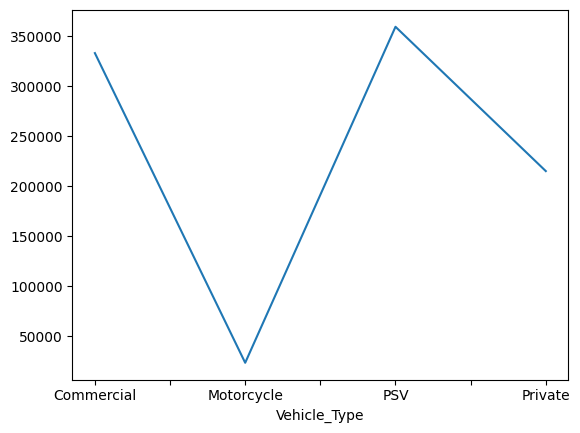

In [30]:
df.groupby('Vehicle_Type')['Pure_Premium_KES'].mean().plot()